In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')  # Replace with your dataset path


In [5]:
# Display the first few rows of the dataset
df.head()

# Get a summary of the data types and missing values
df.info()

# Get basic statistics for numeric columns
df.describe()

# Check the distribution of categorical features, e.g., 'Survived', 'Pclass', etc.
df['Survived'].value_counts()
df['Pclass'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [8]:
# Filling missing Age values with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Dropping rows with missing Embarked values
df.dropna(subset=['Embarked'], inplace=True)
# Drop the 'Cabin' column due to too many missing values
df.drop(columns=['Cabin'], inplace=True)

df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

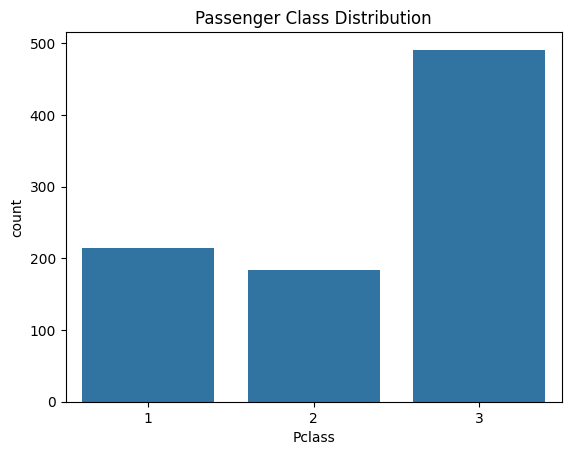

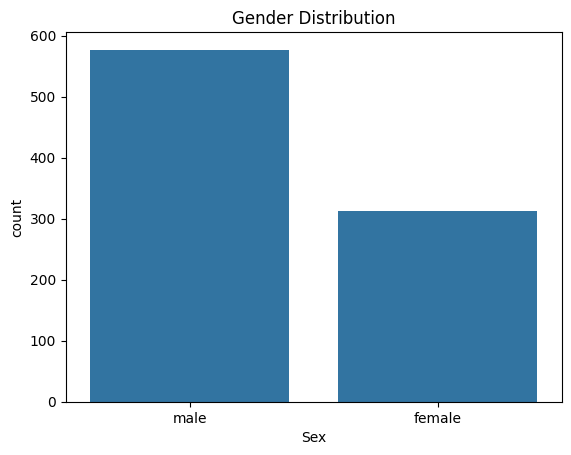

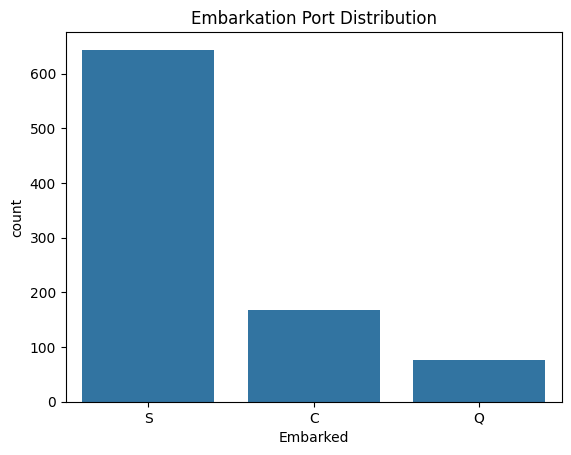

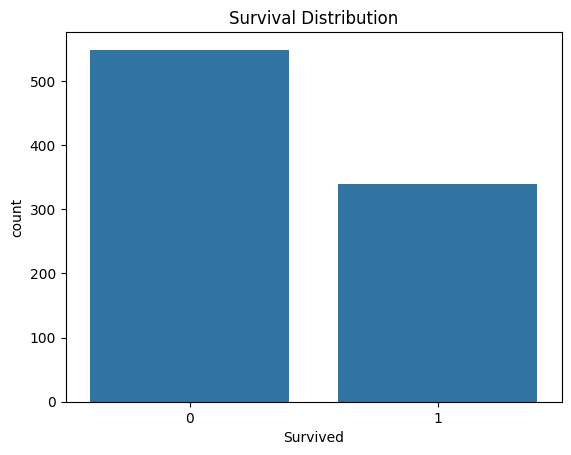

In [9]:
# Plot the distribution of Pclass (Passenger Class)
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

# Plot the distribution of Sex
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()

# Plot the distribution of Embarked (Embarkation Port)
sns.countplot(x='Embarked', data=df)
plt.title('Embarkation Port Distribution')
plt.show()

# Plot the survival distribution (Survived vs Not Survived)
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()


Distribution of Age:

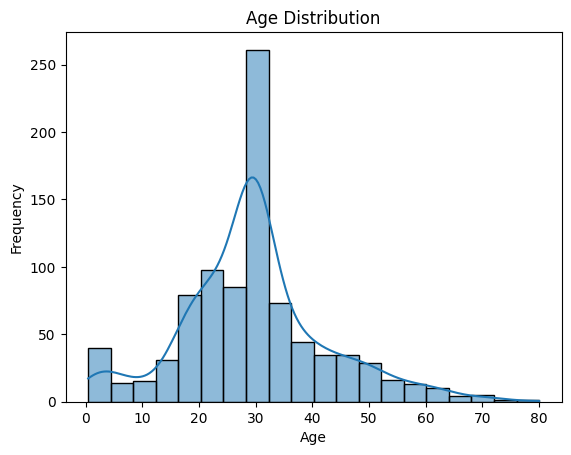

In [10]:
# Plot the distribution of Age
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


Fare Distribution (Histogram)

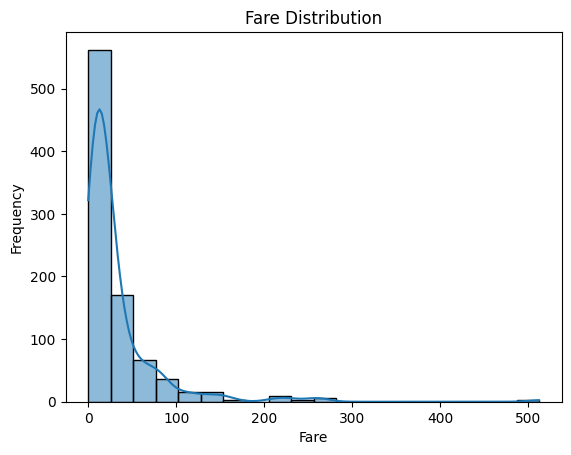

In [11]:
# Plot the distribution of Fare
sns.histplot(df['Fare'], kde=True, bins=20)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()


 Survival by Gender:

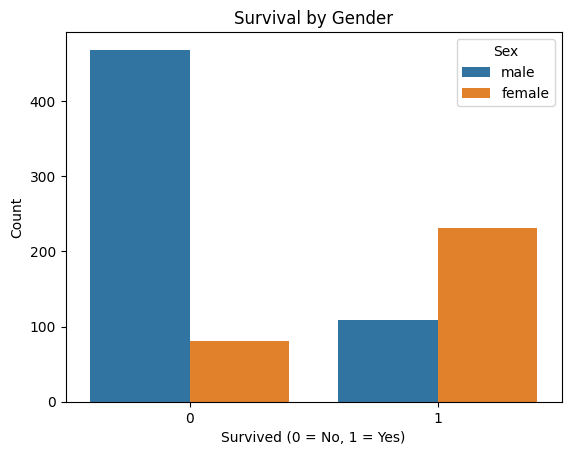

In [22]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


Age vs. Survival (Boxplot):

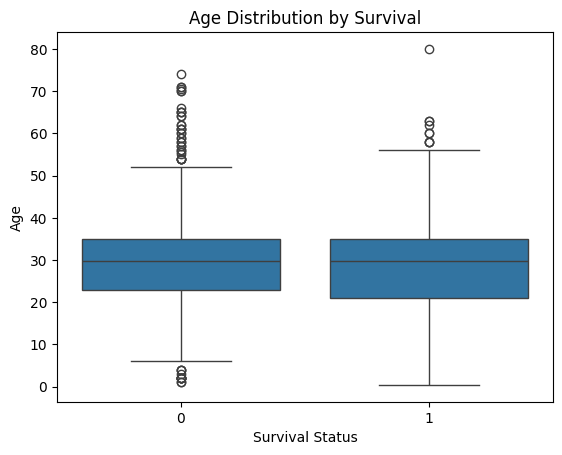

In [12]:
# Boxplot to visualize Age distribution by Survival status
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.xlabel('Survival Status')
plt.ylabel('Age')
plt.show()


Correlation Heatmap:

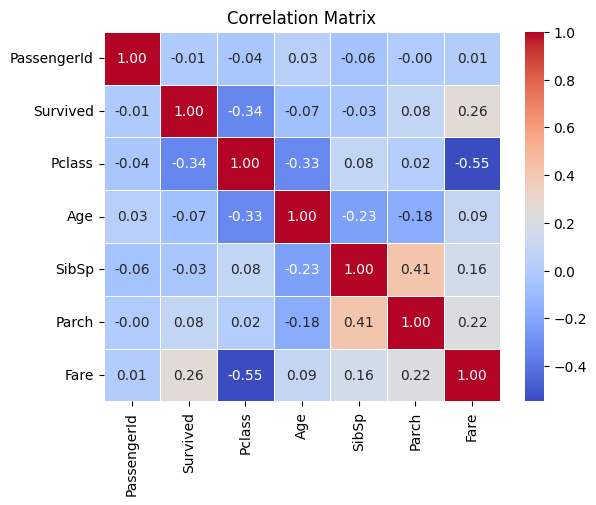

In [14]:
# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])

# Create a correlation matrix for numerical features
correlation_matrix = numeric_df.corr()

# Visualize the correlation matrix with a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


 Pairplot (Age, Fare, Survived):

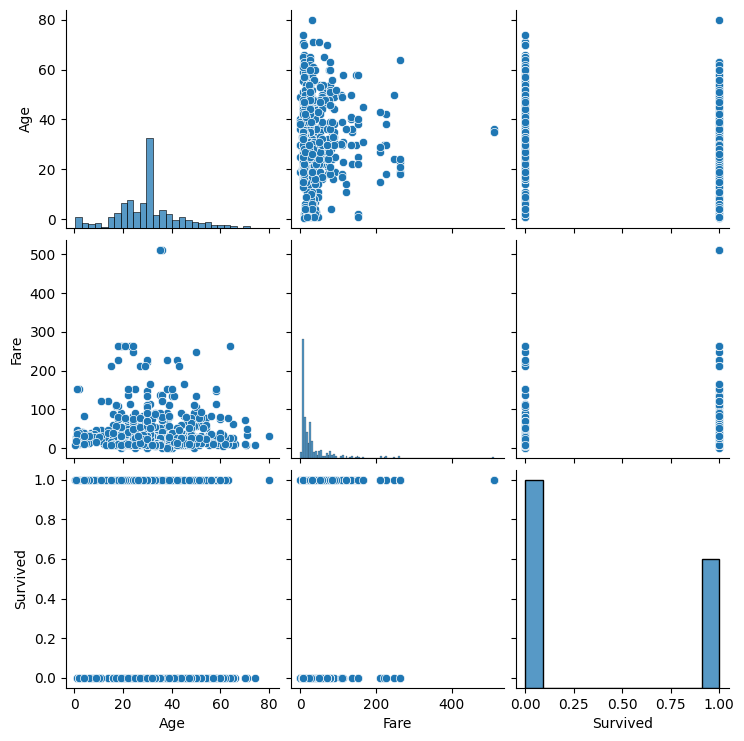

In [15]:
# Create a pairplot to explore relationships between Age, Fare, and Survived
sns.pairplot(df[['Age', 'Fare', 'Survived']])
plt.show()


In [18]:
# Check correlation of all features with 'Survived'
correlation_with_survived = df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)
print(correlation_with_survived)


Survived       1.000000
Fare           0.255290
Parch          0.083151
PassengerId   -0.005028
SibSp         -0.034040
Age           -0.074673
Pclass        -0.335549
Name: Survived, dtype: float64
